# Notebook 04 - Champ de mouvement Lucas-Kanade

Nous avons pour objectif d'estimer un champ de mouvement sparse entre deux frames successives.

In [6]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import matplotlib.pyplot as plt

from src.preprocessing import load_image, load_image_sequence, preprocess_image
from src.segmentation import otsu_segmentation, adaptive_segmentation, clean_mask, keep_largest_component, paste_roi_mask_to_full_image
from src.detection import detect_good_features, filter_points_inside_mask
from src.optical_flow import compute_lucas_kanade, filter_valid_flow
from src.trajectory import filter_points_by_displacement
from src.visualization import draw_points, draw_motion_field

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Detection initiale des points

Nous red?tectons les points dans la m?me logique que le notebook 03 : ROI manuelle, segmentation, puis points caract?ristiques.

In [7]:
image_paths = load_image_sequence(IMG_DIR)
frame0 = load_image(image_paths[0])
frame1 = load_image(image_paths[1])
gray0 = preprocess_image(frame0)
gray1 = preprocess_image(frame1)

roi = (535, 300, 225, 105)
x, y, w, h = roi
mask_roi = keep_largest_component(clean_mask(otsu_segmentation(gray0[y:y+h, x:x+w]), kernel_size=(5, 5), closing_iter=2, opening_iter=1))
mask = paste_roi_mask_to_full_image(mask_roi, gray0.shape, roi)
points0 = detect_good_features(gray0, mask, maxCorners=80, qualityLevel=0.01, minDistance=7, blockSize=7)
points0 = filter_points_inside_mask(points0, mask)
print("Points initiaux:", len(points0))

Points initiaux: 60


## Application de Lucas-Kanade

Lucas-Kanade repose sur trois hypoth?ses importantes : petits d?placements, illumination constante et mouvement local constant. Le champ obtenu est sparse car il est calcul? uniquement sur les points caract?ristiques.

In [8]:
lk_params = dict(
    winSize=(15, 15),
    maxLevel=2,
    criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03),
)

points1, status, error = compute_lucas_kanade(gray0, gray1, points0, lk_params)
old_valid, new_valid = filter_valid_flow(points0, points1, status)
old_valid, new_valid = filter_points_by_displacement(old_valid, new_valid, max_displacement=30)
print("Points suivis valides:", len(new_valid))

Points suivis valides: 60


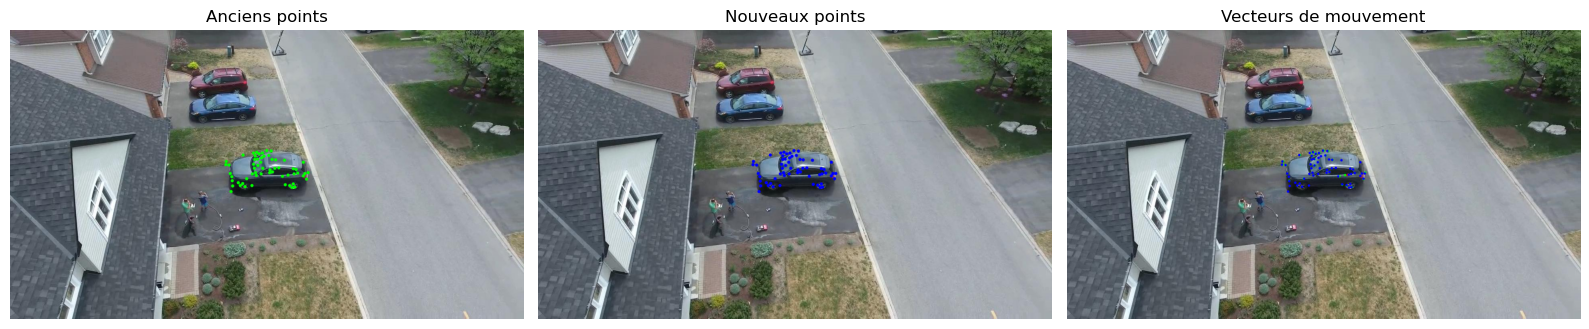

In [9]:
old_points_frame = draw_points(frame0, old_valid, color=(0, 255, 0))
new_points_frame = draw_points(frame1, new_valid, color=(255, 0, 0))
motion_field = draw_motion_field(frame1, old_valid, new_valid)
cv2.imwrite(str(FRAMES_DIR / "motion_field_frame.png"), motion_field)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(cv2.cvtColor(old_points_frame, cv2.COLOR_BGR2RGB)); axes[0].set_title("Anciens points")
axes[1].imshow(cv2.cvtColor(new_points_frame, cv2.COLOR_BGR2RGB)); axes[1].set_title("Nouveaux points")
axes[2].imshow(cv2.cvtColor(motion_field, cv2.COLOR_BGR2RGB)); axes[2].set_title("Vecteurs de mouvement")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

Nous observons des vecteurs de d?placement entre les deux frames. Ces vecteurs forment le champ de mouvement sparse de la voiture.

## Test sur plusieurs paires de frames

Nous testons rapidement quelques paires successives pour v?rifier la stabilit? du suivi local.

In [10]:
for start_idx in [0, 10, 20, 30]:
    prev = load_image(image_paths[start_idx])
    curr = load_image(image_paths[start_idx + 1])
    prev_gray = preprocess_image(prev)
    curr_gray = preprocess_image(curr)
    p_new, st, err = compute_lucas_kanade(prev_gray, curr_gray, points0, lk_params)
    p_old_valid, p_new_valid = filter_valid_flow(points0, p_new, st)
    p_old_valid, p_new_valid = filter_points_by_displacement(p_old_valid, p_new_valid, max_displacement=30)
    print(f"Frames {start_idx}->{start_idx+1}: {len(p_new_valid)} points valides")

Frames 0->1: 60 points valides
Frames 10->11: 60 points valides
Frames 20->21: 60 points valides
Frames 30->31: 60 points valides


Nous interpr?tons ces nombres comme un indicateur de suivi. Si trop peu de points restent valides, il faut red?tecter des points autour du dernier centre estim?.